# Sales Analysis

This notebook analyzes the cleaned sales dataset for the Italian Restaurant Analytics project.

The objective is to identify sales trends, category performance, monthly variations, and key business insights using Python.

## Analysis Scope

- Monthly sales evolution
- Sales performance by category
- Highest and lowest sales periods
- Category contribution to total sales
- Key trends and business insights

In [29]:
# Import the libraries required for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt

# Import currency formatting tools for chart axes

from matplotlib.ticker import FuncFormatter

In [3]:
# Load the cleaned sales dataset and display the first five rows

df = pd.read_excel("../data/cleaned/sales_cleaned.xlsx")
df.head()

,Date,Category,Sales
0,2025-03-01,Food,74471.064
1,2025-03-01,Beverages,12902.220
2,2025-03-01,Events,1957.200
3,2025-03-01,Liquor,14545.870
4,2025-04-01,Food,61905.340


In [4]:
# Inspect the dataset structure, size, and data types

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (52, 3)

Column names:
['Date', 'Category', 'Sales']

Data types:
Date        datetime64[ns]
Category            object
Sales              float64
dtype: object


## Sales Summary

This section provides a general overview of the sales dataset using key summary metrics, including total sales, average sales, and the highest and lowest recorded sales values.

In [5]:
# Calculate key sales summary metrics

total_sales = df["Sales"].sum()
average_sales = df["Sales"].mean()
highest_sales = df["Sales"].max()
lowest_sales = df["Sales"].min()

print(f"Total sales: ${total_sales:,.2f}")
print(f"Average sales: ${average_sales:,.2f}")
print(f"Highest sales value: ${highest_sales:,.2f}")
print(f"Lowest sales value: ${lowest_sales:,.2f}")

Total sales: $1,344,807.28
Average sales: $25,861.68
Highest sales value: $86,570.79
Lowest sales value: $1,343.60


## Monthly Sales Trend

This section analyzes total sales by month to identify overall sales trends, peak periods, and lower-performing months throughout the analyzed period.

In [7]:
# Aggregate total sales by month and display the monthly results

monthly_sales = df.groupby("Date")["Sales"].sum().reset_index()

monthly_sales.style.format({
    "Sales": "${:,.2f}"
})


,Date,Sales
0,2025-03-01 00:00:00,"$103,876.35"
1,2025-04-01 00:00:00,"$86,374.69"
2,2025-05-01 00:00:00,"$102,869.21"
3,2025-06-01 00:00:00,"$100,154.40"
4,2025-07-01 00:00:00,"$100,600.17"
5,2025-08-01 00:00:00,"$98,279.11"
6,2025-09-01 00:00:00,"$91,959.74"
7,2025-10-01 00:00:00,"$102,360.35"
8,2025-11-01 00:00:00,"$114,970.30"
9,2025-12-01 00:00:00,"$131,135.53"


### Monthly Sales Visualization

The following line chart shows how total monthly sales evolved throughout the analyzed period, making it easier to identify growth patterns, declines, and peak sales months.

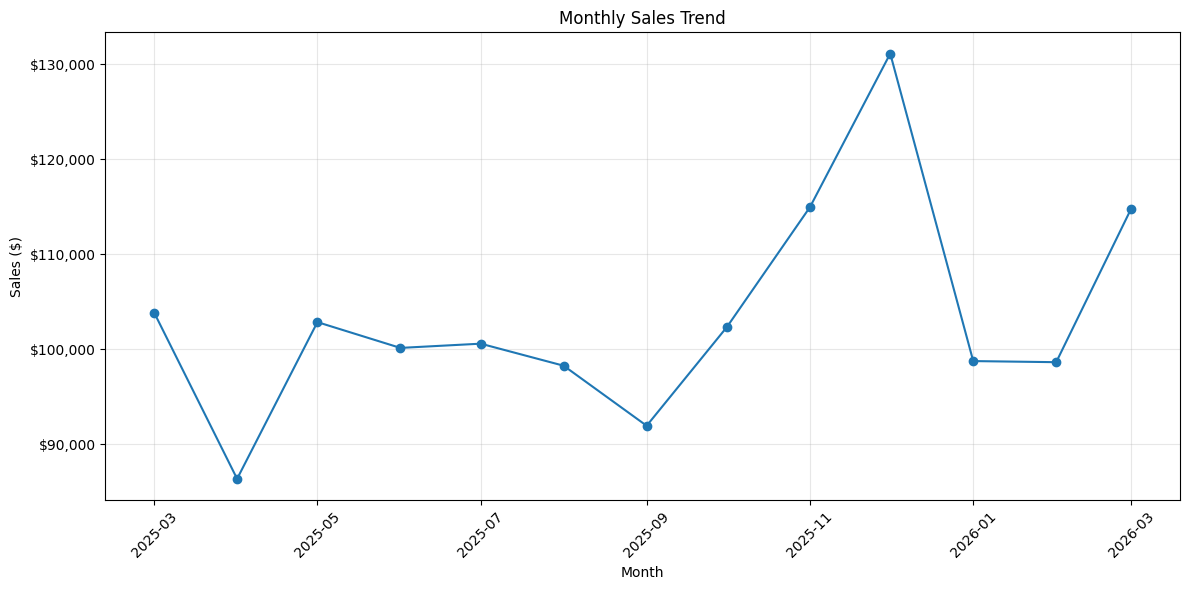

In [10]:
# Create a line chart to visualize the monthly sales trend with currency formatting

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")

plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

Monthly sales remained relatively stable around the $100,000 level for much of the analyzed period. December 2025 recorded the highest monthly sales, while April 2025 represented the lowest-performing month. Sales recovered strongly by March 2026 after softer results in January and February.

## Sales by Category

This section analyzes total sales by category to identify which areas of the business contribute the most to overall revenue.



In [11]:
# Aggregate total sales by category and display the results formatted as currency

category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_sales.style.format({
    "Sales": "${:,.2f}"
})

,Category,Sales
0,Food,"$948,232.21"
1,Liquor,"$211,747.70"
2,Beverages,"$157,079.85"
3,Events,"$27,747.52"


### Category Sales Visualization

The following bar chart compares total sales across categories, highlighting the relative contribution of each category to overall revenue.

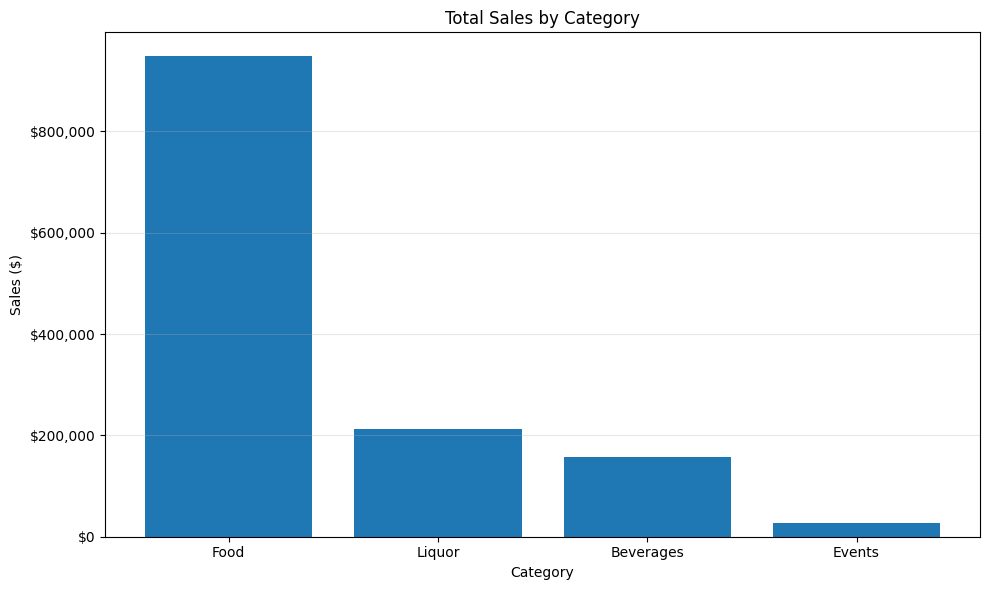

In [12]:
# Create a bar chart to compare total sales by category

plt.figure(figsize=(10, 6))

plt.bar(
    category_sales["Category"],
    category_sales["Sales"]
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

Food clearly dominates total sales, generating substantially more revenue than all other categories combined individually. Liquor and Beverages represent secondary revenue streams, while Events contributes only a small portion of total sales.

This distribution shows that the restaurant's revenue structure is heavily concentrated in Food, making this category the primary driver of overall business performance.

### Category Contribution to Total Sales

This section calculates the percentage contribution of each category to total sales, helping quantify the relative importance of each revenue source.

In [13]:
# Calculate the percentage contribution of each category to total sales

category_sales["Contribution (%)"] = (
    category_sales["Sales"] / category_sales["Sales"].sum()
) * 100

category_sales.style.format({
    "Sales": "${:,.2f}",
    "Contribution (%)": "{:.2f}%"
})

,Category,Sales,Contribution (%)
0,Food,"$948,232.21",70.51%
1,Liquor,"$211,747.70",15.75%
2,Beverages,"$157,079.85",11.68%
3,Events,"$27,747.52",2.06%


### Category Contribution Visualization

The following chart shows the percentage contribution of each category to total sales, making it easier to compare the relative importance of each revenue source.

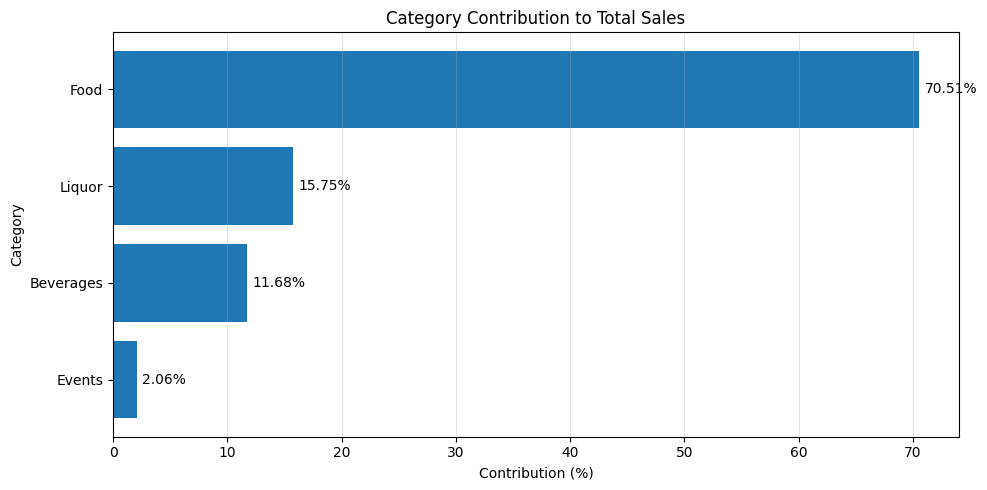

In [15]:
# Create a horizontal bar chart to visualize category contribution to total sales

plt.figure(figsize=(10, 5))

bars = plt.barh(
    category_sales["Category"],
    category_sales["Contribution (%)"]
)

plt.title("Category Contribution to Total Sales")
plt.xlabel("Contribution (%)")
plt.ylabel("Category")

plt.gca().invert_yaxis()

# Add percentage labels at the end of each bar
for bar, value in zip(bars, category_sales["Contribution (%)"]):
    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

Food accounts for 70.51% of total sales, making it by far the most important revenue category. Liquor contributes 15.75%, followed by Beverages at 11.68%, while Events represents only 2.06% of total revenue.

This concentration shows that the restaurant is highly dependent on Food sales. While this category is clearly the core business driver, the relatively smaller contribution from Liquor, Beverages, and Events may represent opportunities for revenue diversification.

## Monthly Sales by Category

This section analyzes the monthly evolution of each sales category to identify category-specific trends, seasonal changes, and variations in revenue performance over time.

In [16]:
# Reshape the dataset to compare monthly sales across categories

monthly_category_sales = df.pivot(
    index="Date",
    columns="Category",
    values="Sales"
)

monthly_category_sales

Category,Beverages,Events,Food,Liquor
Date,,,,
2025-03-01,12902.22,1957.20,74471.064,14545.87
2025-04-01,10820.64,1386.30,61905.340,12262.41
2025-05-01,12085.67,1451.04,72580.850,16751.65
2025-06-01,11217.33,1608.90,69935.370,17392.80
2025-07-01,11420.19,1610.41,69981.820,17587.75
2025-08-01,10942.75,1878.20,68547.960,16910.20
2025-09-01,10734.60,1520.70,64423.840,15280.60
2025-10-01,11965.54,1482.48,71959.680,16952.65
2025-11-01,14151.51,1972.93,83971.260,14874.60


### Monthly Category Sales Visualization

The following line chart compares the monthly sales evolution of all categories, allowing changes in category performance to be observed over time.

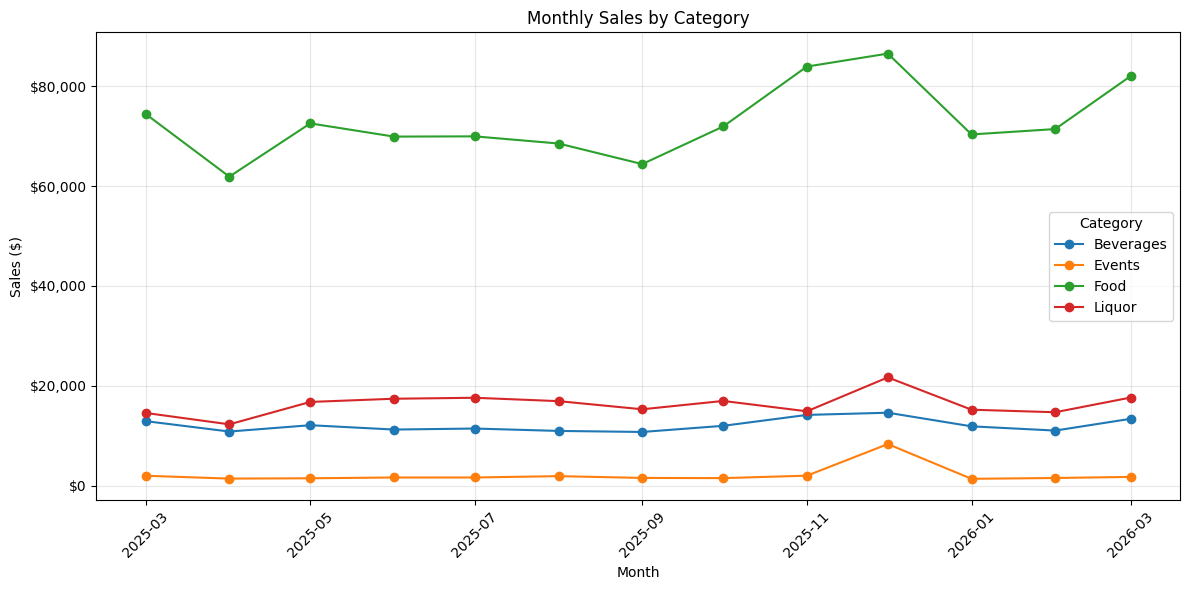

In [17]:
# Create a line chart to compare monthly sales trends across all categories

plt.figure(figsize=(12, 6))

for category in monthly_category_sales.columns:
    plt.plot(
        monthly_category_sales.index,
        monthly_category_sales[category],
        marker="o",
        label=category
    )

plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.xticks(rotation=45)

plt.legend(title="Category")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

Food remained the leading sales category throughout the entire analyzed period, consistently outperforming all other revenue sources. Liquor maintained the second-highest sales level, while Beverages showed a relatively stable monthly pattern.

December 2025 stands out as the strongest month across multiple categories, with particularly noticeable increases in Food, Liquor, and Events. This suggests a broad seasonal sales boost rather than growth driven by a single category.

## Best and Worst Performing Months

This section identifies the highest and lowest sales months during the analyzed period, helping highlight the strongest and weakest points in overall monthly performance.

In [18]:
# Identify the highest and lowest performing months based on total sales

best_month = monthly_sales.loc[monthly_sales["Sales"].idxmax()]
worst_month = monthly_sales.loc[monthly_sales["Sales"].idxmin()]

sales_difference = best_month["Sales"] - worst_month["Sales"]

print(
    f"Best month: {best_month['Date'].strftime('%B %Y')} "
    f"- ${best_month['Sales']:,.2f}"
)

print(
    f"Worst month: {worst_month['Date'].strftime('%B %Y')} "
    f"- ${worst_month['Sales']:,.2f}"
)

print(f"Sales difference: ${sales_difference:,.2f}")

Best month: December 2025 - $131,135.53
Worst month: April 2025 - $86,374.69
Sales difference: $44,760.84


### Best vs Worst Month Visualization

The following bar chart compares the highest and lowest monthly sales values, highlighting the magnitude of the performance gap between the strongest and weakest months.

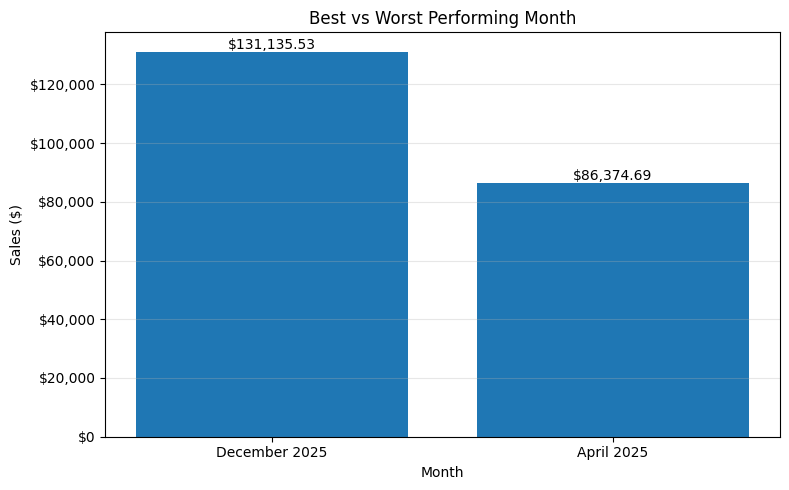

In [19]:
# Create a bar chart to compare the best and worst performing months

comparison_months = pd.DataFrame({
    "Month": [
        best_month["Date"].strftime("%B %Y"),
        worst_month["Date"].strftime("%B %Y")
    ],
    "Sales": [
        best_month["Sales"],
        worst_month["Sales"]
    ]
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparison_months["Month"],
    comparison_months["Sales"]
)

plt.title("Best vs Worst Performing Month")
plt.xlabel("Month")
plt.ylabel("Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

# Add sales labels above each bar
for bar, value in zip(bars, comparison_months["Sales"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1000,
        f"${value:,.2f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

December 2025 was the strongest month in the analyzed period, generating $131,135.53 in total sales, while April 2025 recorded the lowest performance at $86,374.69.

The $44,760.84 gap between the two months represents a substantial variation in monthly revenue. Combined with the category-level analysis, the December peak appears to reflect broad-based growth across several revenue categories rather than an isolated increase in a single area.

## Month-over-Month Sales Growth

This section measures the percentage change in total sales from one month to the next, helping identify periods of acceleration, slowdown, and sudden changes in monthly performance.

In [20]:
# Calculate month-over-month percentage change in total sales

monthly_sales["MoM Growth (%)"] = monthly_sales["Sales"].pct_change() * 100

monthly_sales.style.format({
    "Sales": "${:,.2f}",
    "MoM Growth (%)": "{:.2f}%"
})

,Date,Sales,MoM Growth (%)
0,2025-03-01 00:00:00,"$103,876.35",nan%
1,2025-04-01 00:00:00,"$86,374.69",-16.85%
2,2025-05-01 00:00:00,"$102,869.21",19.10%
3,2025-06-01 00:00:00,"$100,154.40",-2.64%
4,2025-07-01 00:00:00,"$100,600.17",0.45%
5,2025-08-01 00:00:00,"$98,279.11",-2.31%
6,2025-09-01 00:00:00,"$91,959.74",-6.43%
7,2025-10-01 00:00:00,"$102,360.35",11.31%
8,2025-11-01 00:00:00,"$114,970.30",12.32%
9,2025-12-01 00:00:00,"$131,135.53",14.06%


### Month-over-Month Growth Visualization

The following chart shows the monthly percentage change in total sales, making it easier to identify periods of growth, decline, and significant shifts in performance.

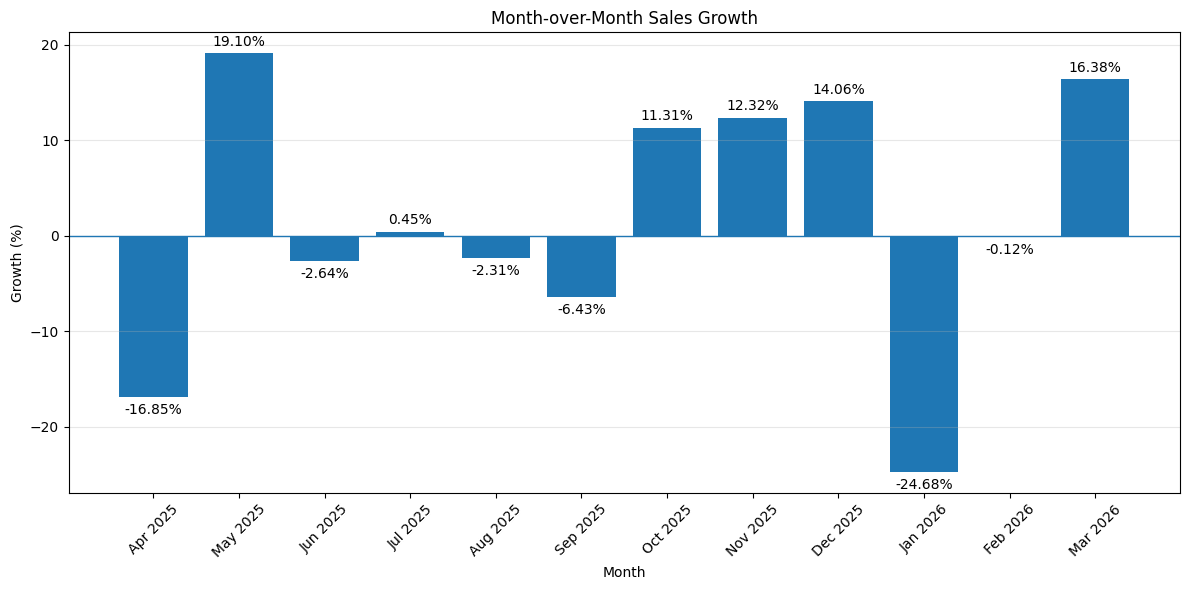

In [22]:
# Create a clearer bar chart for month-over-month sales growth using month labels

growth_data = monthly_sales.dropna(subset=["MoM Growth (%)"]).copy()

growth_data["Month"] = growth_data["Date"].dt.strftime("%b %Y")

plt.figure(figsize=(12, 6))

bars = plt.bar(
    growth_data["Month"],
    growth_data["MoM Growth (%)"]
)

plt.title("Month-over-Month Sales Growth")
plt.xlabel("Month")
plt.ylabel("Growth (%)")

plt.axhline(0, linewidth=1)

# Add percentage labels to each bar
for bar, value in zip(bars, growth_data["MoM Growth (%)"]):
    y_position = value + 0.8 if value >= 0 else value - 1.8

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y_position,
        f"{value:.2f}%",
        ha="center"
    )

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The strongest month-over-month increase occurred in May 2025, when sales grew by 19.10% compared with April. March 2026 also showed a strong recovery, with growth of 16.38%.

The sharpest decline occurred in January 2026, when sales fell by 24.68% following the December peak. April 2025 also recorded a significant decrease of 16.85%.

Overall, the results show periods of relatively stable performance interrupted by a few pronounced increases and declines, suggesting that seasonal or event-driven factors may have a meaningful impact on monthly sales.

## Sales Volatility and Stability

This section evaluates the consistency of monthly sales by measuring their average, standard deviation, and coefficient of variation.

These metrics help determine whether monthly revenue remained relatively stable or experienced significant fluctuations during the analyzed period.

In [23]:
# Measure monthly sales stability using the mean, standard deviation, and coefficient of variation

monthly_average = monthly_sales["Sales"].mean()
monthly_std = monthly_sales["Sales"].std()
coefficient_variation = (monthly_std / monthly_average) * 100

print(f"Average monthly sales: ${monthly_average:,.2f}")
print(f"Monthly sales standard deviation: ${monthly_std:,.2f}")
print(f"Coefficient of variation: {coefficient_variation:.2f}%")

Average monthly sales: $103,446.71
Monthly sales standard deviation: $11,343.77
Coefficient of variation: 10.97%


### Sales Stability Visualization

The following chart compares monthly sales against the average monthly sales level, helping identify periods that performed above or below the typical monthly revenue.

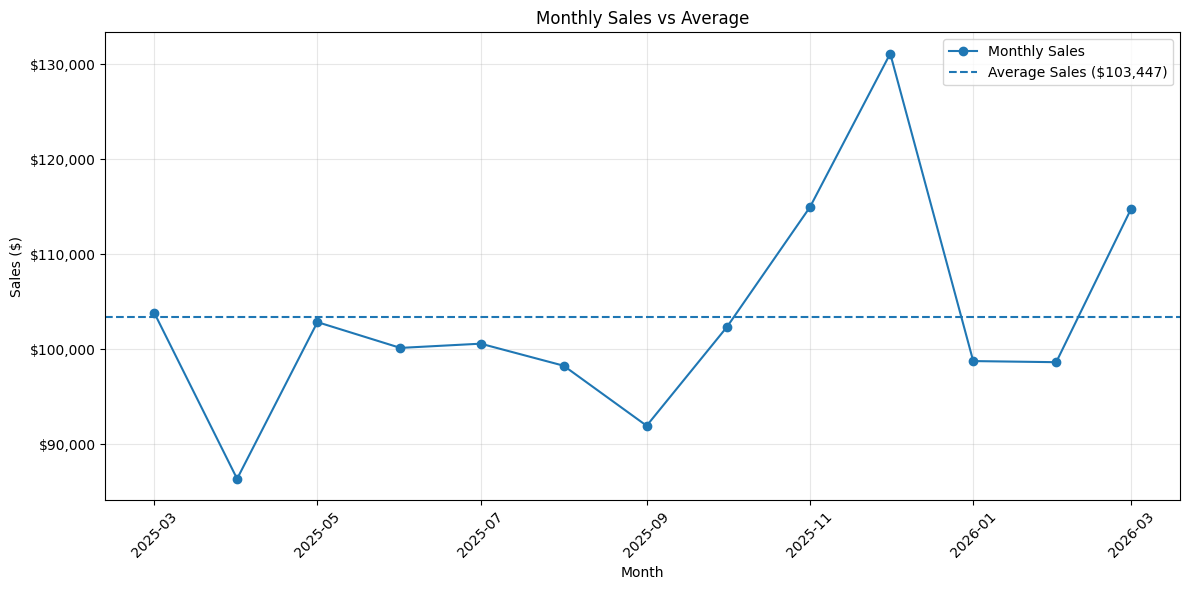

In [24]:
# Compare monthly sales with the average monthly sales level

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    marker="o",
    label="Monthly Sales"
)

plt.axhline(
    monthly_average,
    linestyle="--",
    label=f"Average Sales (${monthly_average:,.0f})"
)

plt.title("Monthly Sales vs Average")
plt.xlabel("Month")
plt.ylabel("Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

Average monthly sales were $103,446.71, with a standard deviation of $11,343.77 and a coefficient of variation of 10.97%.

The relatively low coefficient of variation indicates that monthly sales were generally stable during the analyzed period, despite several noticeable short-term increases and declines. Most monthly results remained reasonably close to the average, while December 2025 and April 2025 represent the clearest deviations from typical performance.

## Cumulative Sales

This section analyzes the cumulative progression of total sales throughout the period, showing how revenue builds over time and highlighting the overall growth of the business.

In [25]:
# Calculate cumulative sales over time and display the results

monthly_sales["Cumulative Sales"] = monthly_sales["Sales"].cumsum()

monthly_sales[["Date", "Sales", "Cumulative Sales"]].style.format({
    "Sales": "${:,.2f}",
    "Cumulative Sales": "${:,.2f}"
})

,Date,Sales,Cumulative Sales
0,2025-03-01 00:00:00,"$103,876.35","$103,876.35"
1,2025-04-01 00:00:00,"$86,374.69","$190,251.04"
2,2025-05-01 00:00:00,"$102,869.21","$293,120.25"
3,2025-06-01 00:00:00,"$100,154.40","$393,274.65"
4,2025-07-01 00:00:00,"$100,600.17","$493,874.82"
5,2025-08-01 00:00:00,"$98,279.11","$592,153.93"
6,2025-09-01 00:00:00,"$91,959.74","$684,113.67"
7,2025-10-01 00:00:00,"$102,360.35","$786,474.02"
8,2025-11-01 00:00:00,"$114,970.30","$901,444.32"
9,2025-12-01 00:00:00,"$131,135.53","$1,032,579.85"


### Cumulative Sales Visualization

The following chart shows how total sales accumulated throughout the analyzed period, providing a clear view of overall revenue progression over time.

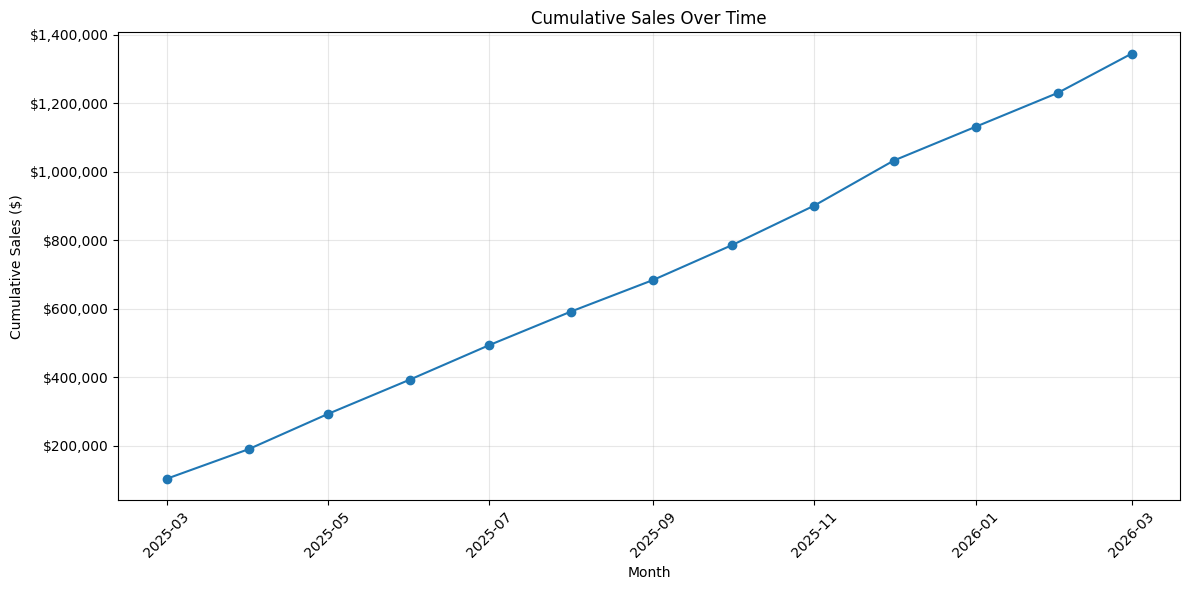

In [26]:
# Create a line chart to visualize cumulative sales over time

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Cumulative Sales"],
    marker="o"
)

plt.title("Cumulative Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Cumulative Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

Cumulative sales increased steadily throughout the analyzed period, reaching a total of $1,344,807.28 by March 2026.

The relatively smooth upward trajectory reflects consistent revenue generation over time, while the slightly steeper growth toward the end of 2025 aligns with the stronger monthly performance observed in November and December.

## Monthly Sales Ranking

This section ranks all months from highest to lowest total sales, providing a complete view of monthly performance across the analyzed period.

In [27]:
# Rank all months from highest to lowest total sales

monthly_ranking = monthly_sales[["Date", "Sales"]].copy()

monthly_ranking["Month"] = monthly_ranking["Date"].dt.strftime("%b %Y")

monthly_ranking = (
    monthly_ranking[["Month", "Sales"]]
    .sort_values("Sales", ascending=False)
    .reset_index(drop=True)
)

monthly_ranking.index = monthly_ranking.index + 1

monthly_ranking.style.format({
    "Sales": "${:,.2f}"
})

,Month,Sales
1,Dec 2025,"$131,135.53"
2,Nov 2025,"$114,970.30"
3,Mar 2026,"$114,807.90"
4,Mar 2025,"$103,876.35"
5,May 2025,"$102,869.21"
6,Oct 2025,"$102,360.35"
7,Jul 2025,"$100,600.17"
8,Jun 2025,"$100,154.40"
9,Jan 2026,"$98,768.26"
10,Feb 2026,"$98,651.27"


### Monthly Sales Ranking Visualization

The following horizontal bar chart ranks all analyzed months from highest to lowest total sales, making it easier to compare overall monthly performance.

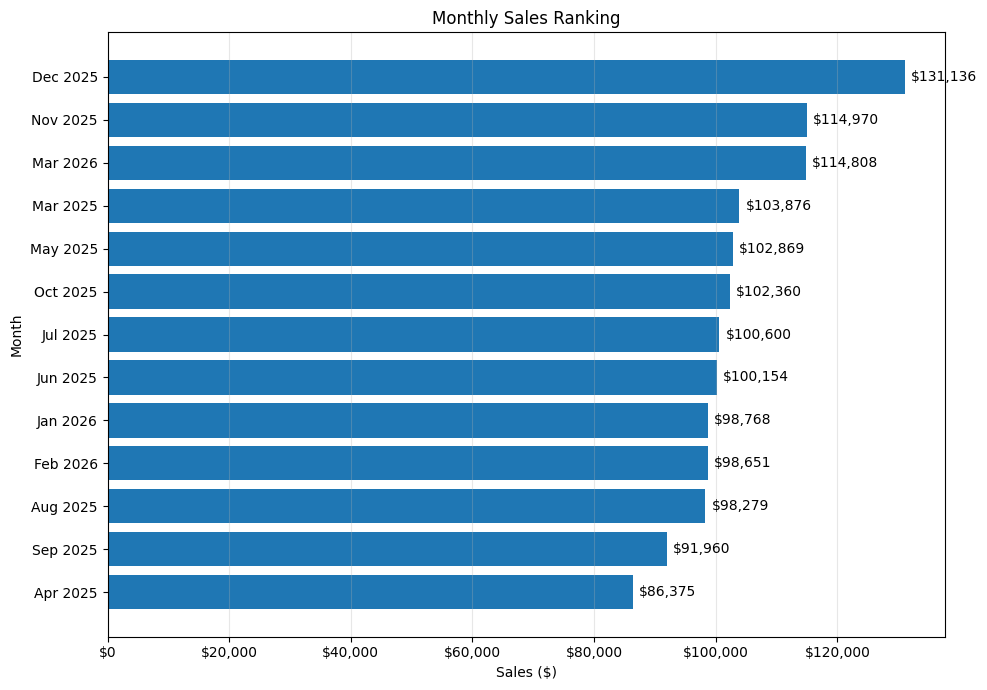

In [28]:
# Create a horizontal bar chart to visualize the monthly sales ranking

plt.figure(figsize=(10, 7))

bars = plt.barh(
    monthly_ranking["Month"],
    monthly_ranking["Sales"]
)

plt.title("Monthly Sales Ranking")
plt.xlabel("Sales ($)")
plt.ylabel("Month")

# Display the highest-selling month at the top
plt.gca().invert_yaxis()

# Format the sales axis as currency
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

# Add sales labels at the end of each bar
for bar, value in zip(bars, monthly_ranking["Sales"]):
    plt.text(
        value + 1000,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

December 2025 ranked as the strongest sales month, reaching approximately $131,136, followed by November 2025 and March 2026 at roughly $114,970 and $114,808 respectively.

At the opposite end, April 2025 recorded the lowest monthly sales at approximately $86,375, followed by September 2025 at about $91,960.

The ranking also shows that most months clustered close to the $100,000 level, reinforcing the earlier finding that overall monthly sales were relatively stable despite a few clear peaks and declines.

## Sales Analysis Summary

The sales analysis shows that the restaurant generated a total of $1,344,807.28 during the analyzed period, with average monthly sales of approximately $103,446.71.

Food was the dominant revenue category, accounting for 70.51% of total sales, followed by Liquor at 15.75% and Beverages at 11.68%. Events contributed only 2.06% of overall revenue.

Monthly sales were generally stable, with a coefficient of variation of 10.97%, although several notable fluctuations were observed. December 2025 was the strongest month, generating $131,135.53, while April 2025 recorded the lowest sales at $86,374.69.

Month-over-month analysis revealed the strongest growth in May 2025 (+19.10%) and the sharpest decline in January 2026 (-24.68%). The strong performance observed toward the end of 2025 was supported by increases across multiple categories rather than a single revenue source.

Overall, the results indicate a relatively stable business with a strong dependence on Food sales and clear seasonal variations that may be relevant for future planning, promotions, inventory management, and revenue diversification.

---

## Author

**Guido Acosta**

Data Analyst Portfolio Project

GitHub Portfolio – 2026